# Tutorial 1A

The first part of the lab on Horizontal Federated Learning, comprised of Tutorials 1A, 1B, and Homework 1, presents the findings and uses part of the experimental methodology from the [original Federated Learning](https://arxiv.org/pdf/1602.05629.pdf) paper. In horizontal federated learning, all clients have access to the same complete model architecture, which they train on local data, sharing information about model updates but not their data.

Before starting, make sure to follow the overall setup for the lab.

This first tutorial sets up some of the prerequisite code for later on and reproduces a basic centralized training setup where the server has all the data and involves no other clients.

---

Before anything else, we download, load, and preprocess the [MNIST dataset](https://archive.ics.uci.edu/dataset/683/mnist+database+of+handwritten+digits), which we will use for all experiments.

In [1]:
from torchvision import datasets, transforms
import torch
from torch.utils.data import DataLoader


data_path_str = "./data"
ETA = "\N{GREEK SMALL LETTER ETA}"
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
torch.backends.cudnn.deterministic=True

transform = transforms.Compose([
    transforms.ToTensor(),
    # normalize by training set mean and standard deviation
    # resulting data has mean=0 and std=1
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(data_path_str, train=True, download=True, transform=transform)
test_loader = DataLoader(
    datasets.MNIST(data_path_str, train=False, download=False, transform=transform),
    # decrease batch size if running into memory issues when testing
    # a bespoke generator is passed to avoid reproducibility issues
    shuffle=False, drop_last=False, batch_size=10000, generator=torch.Generator())

We can then define a small convolutional neural network that will serve as our model.

In [2]:
import torch.nn as nn
import torch.nn.functional as F


class MnistCnn(nn.Module):
    def __init__(self):
        super(MnistCnn, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)

        return output

With that, we can define a helper method, which, given a model, a loader for iterating through a set of data, and an optimizer for updating the model trains one epoch (i.e., learns going through all the available data once).

In [3]:
from torch.optim import Optimizer


def train_epoch(model: torch.nn.Module, loader: DataLoader, optimizer: Optimizer) -> None:
    model.train()

    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()

We also define another utility method that splits the whole dataset into the requested number of chunks, picking samples within chunks in a (non-)IID (independent and identically distributed) fashion.

In [4]:
import numpy as np
import numpy.random as npr
from torch.utils.data import Subset
from typing import cast


def split(nr_clients: int, iid: bool, seed: int) -> list[Subset]:
    rng = npr.default_rng(seed)

    if iid:
        splits = np.array_split(rng.permutation(len(train_dataset)), nr_clients)
    else:
        sorted_indices = np.argsort(np.array([target for _data, target in train_dataset]))
        shards = np.array_split(sorted_indices, 2 * nr_clients)
        shuffled_shard_indices = rng.permutation(len(shards))
        splits = [
            np.concatenate([shards[i] for i in inds], dtype=np.int64)
            for inds in shuffled_shard_indices.reshape(-1, 2)]

    return [Subset(train_dataset, split) for split in cast(list[list[int]], splits)]

In [5]:
sample_split = split(100, True, 42)

We define a short class for holding the results of training runs and the parameters used.

In [6]:
from dataclasses import dataclass, field, asdict
from pandas import DataFrame


@dataclass
class RunResult:
    algorithm: str
    n: int  # number of clients
    c: float  # client_fraction
    b: int  # take -1 as inf
    e: int  # nr_local_epochs
    lr: float  # printed as lowercase eta
    seed: int
    wall_time: list[float] = field(default_factory=list)
    message_count: list[int] = field(default_factory=list)
    test_accuracy: list[float] = field(default_factory=list)

    def as_df(self, skip_wtime=True) -> DataFrame:
        self_dict = {
            k.capitalize().replace("_", " "): v
            for k, v in asdict(self).items()}

        if self_dict["B"] == -1:
            self_dict["B"] = "\N{INFINITY}"

        df = DataFrame({"Round": range(1, len(self.wall_time) + 1), **self_dict})
        df = df.rename(columns={"Lr": ETA})
        if skip_wtime:
            df = df.drop(columns=["Wall time"])
        return df

We create an abstract class as a template for all distributed learning clients, defining a method for outputting an update after training a given model on local data.

In [7]:
from abc import ABC, abstractmethod
from torch.optim import SGD


class Client(ABC):
    def __init__(self, client_data: Subset, batch_size: int) -> None:
        self.model = MnistCnn().to(device)
        self.generator = torch.Generator()
        self.loader_train = DataLoader(
            client_data, batch_size=batch_size, shuffle=True,
            drop_last=False, generator=self.generator)


    @abstractmethod
    def update(self, weights: list[torch.Tensor], seed: int) -> list[torch.Tensor]:
        ...

On the flip side, a server needs to be able to run the (distributed) training process for a given number of rounds and test the current model it possesses.

In [8]:
class Server(ABC):
    def __init__(self, lr: float, batch_size: int, seed: int) -> None:
        self.clients: list[Client]
        self.lr = lr
        self.batch_size = batch_size
        self.seed = seed
        torch.manual_seed(seed)
        self.model = MnistCnn().to(device)


    @abstractmethod
    def run(self, nr_rounds: int) -> RunResult:
        ...


    def test(self) -> float:
        correct = 0
        self.model.eval()

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = self.model(data)
                pred = output.argmax(dim=1, keepdim=True)
                correct += pred.eq(target.view_as(pred)).sum().item()

        return 100. * correct / len(cast(datasets.MNIST, test_loader.dataset))

Over the previously defined server template, we can even formulate a centralized variant, which does not involve clients, as a precursor to distributed versions.

In [9]:
from time import perf_counter
from tqdm import tqdm


class CentralizedServer(Server):
    def __init__(self, lr: float, batch_size: int, seed: int) -> None:
        super().__init__(lr, batch_size, seed)
        self.optimizer = SGD(params=self.model.parameters(), lr=lr)
        self.generator = torch.Generator()
        self.loader_train = DataLoader(
            train_dataset, batch_size=batch_size, shuffle=True,
            drop_last=False, generator=self.generator)
        self.clients = []

    def run(self, nr_rounds: int) -> RunResult:
        elapsed_time = 0.
        run_result = RunResult("Centralized", 1, 1, self.batch_size, 1, self.lr, self.seed)

        for epoch in tqdm(range(nr_rounds), desc="Epochs", leave=False):
            start_time = perf_counter()
            self.generator.manual_seed(self.seed + epoch + 1)
            train_epoch(self.model, self.loader_train, self.optimizer)
            elapsed_time += perf_counter() - start_time
            run_result.wall_time.append(round(elapsed_time, 1))
            run_result.message_count.append(0)
            run_result.test_accuracy.append(self.test())

        return run_result

In [10]:
centralized_server = CentralizedServer(0.5, 1024, 42)
result_centralized = centralized_server.run(5)
centralized_df = result_centralized.as_df()
centralized_df

Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

,Round,Algorithm,N,C,B,E,η,Seed,Message count,Test accuracy
0,1,Centralized,1,1,1024,1,0.5,42,0,80.80
1,2,Centralized,1,1,1024,1,0.5,42,0,96.89
2,3,Centralized,1,1,1024,1,0.5,42,0,97.84
3,4,Centralized,1,1,1024,1,0.5,42,0,97.97
4,5,Centralized,1,1,1024,1,0.5,42,0,98.37


We can extend the template with some setup steps common to all decentralized algorithms.

In [11]:
class DecentralizedServer(Server):
    def __init__(self, lr: float, batch_size: int, client_subsets: list[Subset], client_fraction: float, seed: int) -> None:
        super().__init__(lr, batch_size, seed)
        self.nr_clients = len(client_subsets)
        self.client_fraction = client_fraction
        self.client_sample_counts = [len(subset) for subset in client_subsets]
        self.nr_clients_per_round = max(1, round(client_fraction * self.nr_clients))
        self.rng = npr.default_rng(seed)

# Tutorial 1B

The second tutorial implements the two federated learning algorithms from the same paper referenced previously and gives a quick overview of plotting metrics.

---

For the FedSGD algorithm, the baseline from the paper, we first need to define the client, and we choose to pass gradients from the client as the update result.

In [12]:
class GradientClient(Client):
    def __init__(self, client_data: Subset) -> None:
        super().__init__(client_data, len(client_data))

    def update(self, weights: list[torch.Tensor], seed: int) -> list[torch.Tensor]:
        with torch.no_grad():
            for client_values, server_values in zip(self.model.parameters(), weights):
                client_values[:] = server_values
                client_values.grad = None

        # seeding is not strictly necessary here
        self.generator.manual_seed(seed)
        self.model.train()

        # this will always have one iteratioon
        for data, target in self.loader_train:
            data, target = data.to(device), target.to(device)
            output = self.model(data)
            loss = F.nll_loss(output, target)
            loss.backward()

        return [
            cast(torch.Tensor, x.grad).detach().cpu().clone()
            for x in self.model.parameters()]

We then define the corresponding server.

In [13]:
class FedSgdGradientServer(DecentralizedServer):
    def __init__(
            self, lr: float,
            client_subsets: list[Subset], client_fraction: float, seed: int) -> None:
        super().__init__(lr, -1, client_subsets, client_fraction, seed)
        self.optimizer = SGD(params=self.model.parameters(), lr=lr)
        self.clients = [GradientClient(subset) for subset in client_subsets]

    def run(self, nr_rounds: int) -> RunResult:
        elapsed_time = 0.
        run_result = RunResult("FedSGDGradient", self.nr_clients, self.client_fraction, -1, 1, self.lr, self.seed)

        for nr_round in tqdm(range(nr_rounds), desc="Rounds", leave=False):
            setup_start_time = perf_counter()
            self.model.train()
            self.optimizer.zero_grad()
            weights = [x.detach().cpu().clone() for x in self.model.parameters()]
            indices_chosen_clients = self.rng.choice(self.nr_clients, self.nr_clients_per_round, replace=False)
            chosen_sum_nr_samples = sum(self.client_sample_counts[i] for i in indices_chosen_clients)
            chosen_adjusted_gradients: list[list[torch.Tensor]] = []
            elapsed_time += perf_counter() - setup_start_time
            update_time = 0.

            for c_i in indices_chosen_clients:
                update_start_time = perf_counter()
                ind = int(c_i)
                client_round_seed = self.seed + ind + 1 + nr_round * self.nr_clients_per_round
                client_gradients = self.clients[ind].update(weights, client_round_seed)
                chosen_adjusted_gradients.append([
                    self.client_sample_counts[ind] / chosen_sum_nr_samples * tens
                     for tens in client_gradients])
                update_time = max(update_time, perf_counter() - update_start_time)

            elapsed_time += update_time
            aggregate_start_time = perf_counter()
            averaged_chosen_gradients: list[torch.Tensor] = [sum(x) for x in zip(*chosen_adjusted_gradients)]

            with torch.no_grad():
                for client_gradient, server_parameter in zip(averaged_chosen_gradients, self.model.parameters()):
                    server_parameter.grad = client_gradient.to(device=device)

            self.optimizer.step()
            elapsed_time += perf_counter() - aggregate_start_time
            run_result.wall_time.append(round(elapsed_time, 1))
            run_result.message_count.append(2 * (nr_round + 1) * self.nr_clients_per_round)
            run_result.test_accuracy.append(self.test())

        return run_result

In [14]:
fedsgd_gradient_server = FedSgdGradientServer(0.02, sample_split, 0.2, 42)
result_fedsgd_gradient = fedsgd_gradient_server.run(5)
fedsgd_gradient_df = result_fedsgd_gradient.as_df()
fedsgd_gradient_df

,Round,Algorithm,N,C,B,E,η,Seed,Message count,Test accuracy
0,1,FedSGDGradient,100,0.2,∞,1,0.02,42,40,8.89
1,2,FedSGDGradient,100,0.2,∞,1,0.02,42,80,9.47
2,3,FedSGDGradient,100,0.2,∞,1,0.02,42,120,10.31
3,4,FedSGDGradient,100,0.2,∞,1,0.02,42,160,12.56
4,5,FedSGDGradient,100,0.2,∞,1,0.02,42,200,15.72


The FedAvg algorithm is the paper's main contribution, requiring a client that passes around weights instead of gradients.

In [15]:
class WeightClient(Client):
    def __init__(self, client_data: Subset, lr: float, batch_size: int, nr_epochs: int) -> None:
        super().__init__(client_data, batch_size)
        self.optimizer = SGD(params=self.model.parameters(), lr=lr)
        self.nr_epochs = nr_epochs


    def update(self, weights: list[torch.Tensor], seed: int) -> list[torch.Tensor]:
        with torch.no_grad():
            for client_values, server_values in zip(self.model.parameters(), weights):
                client_values[:] = server_values

        self.generator.manual_seed(seed)

        for _epoch in range(self.nr_epochs):
            train_epoch(self.model, self.loader_train, self.optimizer)

        return [x.detach().cpu().clone() for x in self.model.parameters()]

Following that, we define the actual server code for the method.

In [16]:
class FedAvgServer(DecentralizedServer):
    def __init__(
            self, lr: float, batch_size: int, client_subsets: list[Subset],
            client_fraction: float, nr_local_epochs: int, seed: int) -> None:
        super().__init__(lr, batch_size, client_subsets, client_fraction, seed)
        self.name = "FedAvg"
        self.nr_local_epochs = nr_local_epochs
        self.clients = [
            WeightClient(subset, lr, batch_size, nr_local_epochs)
            for subset in client_subsets]

    def run(self, nr_rounds: int) -> RunResult:
        elapsed_time = 0.
        run_result = RunResult(self.name, self.nr_clients, self.client_fraction, self.batch_size, self.nr_local_epochs, self.lr, self.seed)

        for nr_round in tqdm(range(nr_rounds), desc="Rounds", leave=False):
            setup_start_time = perf_counter()
            self.model.train()
            weights = [x.detach().cpu().clone() for x in self.model.parameters()]
            indices_chosen_clients = self.rng.choice(self.nr_clients, self.nr_clients_per_round, replace=False)
            chosen_sum_nr_samples = sum(self.client_sample_counts[i] for i in indices_chosen_clients)
            chosen_adjusted_weights: list[list[torch.Tensor]] = []
            elapsed_time += perf_counter() - setup_start_time
            update_time = 0.

            for c_i in indices_chosen_clients:
                update_start_time = perf_counter()
                ind = int(c_i)
                client_round_seed = self.seed + ind + 1 + nr_round * self.nr_clients_per_round
                client_weights = self.clients[ind].update(weights, client_round_seed)
                chosen_adjusted_weights.append([
                    self.client_sample_counts[ind] / chosen_sum_nr_samples * tens
                     for tens in client_weights])
                update_time = max(update_time, perf_counter() - update_start_time)

            elapsed_time += update_time
            aggregate_start_time = perf_counter()
            averaged_chosen_weights: list[torch.Tensor] = [sum(x) for x in zip(*chosen_adjusted_weights)]

            with torch.no_grad():
                for client_weight, server_parameter in zip(averaged_chosen_weights, self.model.parameters()):
                    server_parameter[:] = client_weight.to(device=device)

            elapsed_time += perf_counter() - aggregate_start_time
            run_result.wall_time.append(round(elapsed_time, 1))
            run_result.message_count.append(2 * (nr_round + 1) * self.nr_clients_per_round)
            run_result.test_accuracy.append(self.test())

        return run_result

In [17]:
fedavg_server = FedAvgServer(0.02, 200, sample_split, 0.2, 2, 42)
result_fedavg = fedavg_server.run(5)
fedavg_df = result_fedavg.as_df()
fedavg_df

,Round,Algorithm,N,C,B,E,η,Seed,Message count,Test accuracy
0,1,FedAvg,100,0.2,200,2,0.02,42,40,20.95
1,2,FedAvg,100,0.2,200,2,0.02,42,80,54.43
2,3,FedAvg,100,0.2,200,2,0.02,42,120,67.54
3,4,FedAvg,100,0.2,200,2,0.02,42,160,75.09
4,5,FedAvg,100,0.2,200,2,0.02,42,200,77.24


Finally, we look at a quick example of plotting the accuracy per round of the two algorithms.

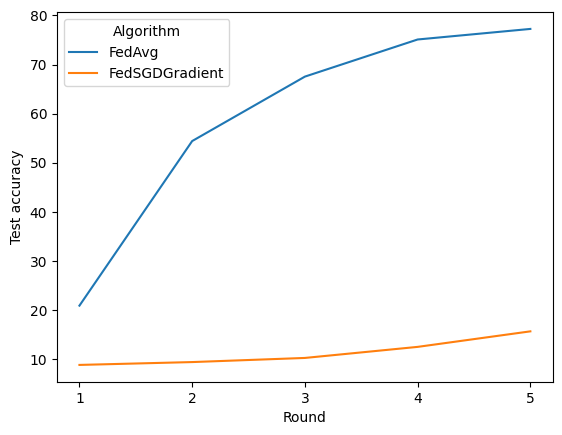

In [18]:
import pandas as pd
import seaborn as sns


df = pd.concat([fedavg_df, fedsgd_gradient_df], ignore_index=True)
ax = sns.lineplot(df, x="Round", y="Test accuracy", hue="Algorithm", seed=0)
_ = ax.set_xticks(df["Round"].unique())

# Homework 1

When not otherwise specified, use the following parameter values in experiment runs:
- `nr_clients` (N): 100
- `lr`: 0.01
- `client_fraction`(C): 0.1
- `nr_local_epochs` (E): 1
- `batch_size` (B): 100
- `nr_rounds`: 10
- `iid`: True

For all exercises, pass `seed = 10` to calls for splitting data, server initialization, or plotting.

In [19]:
n = 100
lr = 0.01
c = 0.1
e = 1
b = 100
nr_rounds = 10
iid = True
seed = 10

## Exercise 1 - FedSGD with weights

### Question

Implement a version of FedSGD that uses weights in its updates, like FedAvg, instead of the gradients from the version of the tutorials. The two FedSGD versions should have the same test accuracy after each round (with a tolerance of at most 0.01%). To show this, compare their output for the following two scenarios over *5 rounds*:
- `lr = 0.01, client_subsets = split(100, True, ...), client_fraction = 0.5`
- `lr = 0.1, client_subsets = split(50, False, ...), client_fraction = 0.2`

*Tip:* You can use the existing FedAvg implementation to minimize the amount of code writing required.

Explain in which cases (about the different parameters for decentralized learning) the two are equivalent.

### Answer

In [20]:
class FedSgdWeightServer(FedAvgServer):
    def __init__(
            self, lr: float, client_subsets: list[Subset],
            client_fraction: float, seed: int) -> None:
        # any batch size larger than each client's dataset is effectively infinite
        super().__init__(lr, len(train_dataset), client_subsets, client_fraction, 1, seed)
        self.batch_size = -1
        self.name = "FedSGDWeight"

In [21]:
nr_rounds_ = 5

In [22]:
lr_ = 0.01
c_ = 0.5
split_one = split(100, True, seed)

fedsgd_gradient_server_one = FedSgdGradientServer(lr_, split_one, c_, seed)
fedsgd_gradient_df_one =  fedsgd_gradient_server_one.run(nr_rounds_).as_df()

fedsgd_weight_server_one = FedSgdWeightServer(lr_, split_one, c_, seed)
fedsgd_weight_df_one =  fedsgd_weight_server_one.run(nr_rounds_).as_df()

diff_acc_one = fedsgd_gradient_df_one["Test accuracy"] - fedsgd_weight_df_one["Test accuracy"]

if (diff_acc_one.abs() > 0.01).any():
    raise AssertionError("Results are unequal")

"OK"

'OK'

In [23]:
lr_ = 0.1
c_ = 0.2
split_other = split(50, False, seed)

fedsgd_gradient_server_other = FedSgdGradientServer(lr_, split_other, c_, seed)
fedsgd_gradient_df_other =  fedsgd_gradient_server_other.run(nr_rounds).as_df()

fedsgd_weight_server_other = FedSgdWeightServer(lr_, split_other, c_, seed)
fedsgd_weight_df_other =  fedsgd_weight_server_other.run(nr_rounds).as_df()

diff_acc_other = fedsgd_gradient_df_other["Test accuracy"] - fedsgd_weight_df_other["Test accuracy"]

if (diff_acc_other.abs() > 0.01).any():
    raise AssertionError("Results are unequal")

"OK"

'OK'

Gradient and weight FedSGD are only equivalent when the clients perform one local epoch in each round, and they iterate over all their local data in one step (i.e., their batch size is ∞, or for some local dataset Pₖ of client k, it is greater than or equal to |Pₖ|).

## Exercise 2 - Client number & fraction

### Question

Run the necessary experiments to fill in the following table showing the final message count and test accuracy of FedSGD and FedAvg for different total client numbers:

| Algorithm | N   | C   | Message count | Test accuracy |
| --------- | --- | --- | ------------- | ------------- |
| FedSGD    | 10  | 0.1 |               |               |
| FedAvg    | 10  | 0.1 |               |               |
| FedSGD    | 50  | 0.1 |               |               |
| FedAvg    | 50  | 0.1 |               |               |
| FedSGD    | 100 | 0.1 |               |               |
| FedAvg    | 100 | 0.1 |               |               |

Is the relationship between the metrics and client numbers monotonous?

Run the experiments to fill in the table when varying the fraction of clients used in every round:

| Algorithm | N   | C    | Message count | Test accuracy |
| --------- | --- | ---- | ------------- | ------------- |
| FedSGD    | 100 | 0.01 |               |               |
| FedAvg    | 100 | 0.01 |               |               |
| FedSGD    | 100 | 0.1  |               |               |
| FedAvg    | 100 | 0.1  |               |               |
| FedSGD    | 100 | 0.2  |               |               |
| FedAvg    | 100 | 0.2  |               |               |

How does the observed pattern differ?

### Answer

In [24]:
servers: list[Server] = []

for n_ in [10, 50, 100]:
    client_split = split(n_, iid, seed)
    servers.append(FedSgdGradientServer(lr, client_split, c, seed))
    servers.append(FedAvgServer(lr, b, client_split, c, e, seed))

dfs = [sv.run(nr_rounds).as_df().iloc[-1:] for sv in servers]
df = pd.concat(dfs, ignore_index=True)[["Algorithm", "N", "C", "Message count", "Test accuracy"]]
print(df)

        Algorithm    N    C  Message count  Test accuracy
0  FedSGDGradient   10  0.1             20          43.00
1          FedAvg   10  0.1             20          93.27
2  FedSGDGradient   50  0.1            100          43.50
3          FedAvg   50  0.1            100          87.69
4  FedSGDGradient  100  0.1            200          42.99
5          FedAvg  100  0.1            200          81.06


Increasing the number of clients degrades the accuracy of FedAvg monotonously, but it has little to no effect on FedSGD. The message count always increases with the number of clients, at the same rate, for both algorithms.

In [25]:
servers: list[Server] = []

for c_ in [0.01, 0.1, 0.2]:
    client_split = split(n, iid, seed)
    servers.append(FedSgdGradientServer(lr, client_split, c_, seed))
    servers.append(FedAvgServer(lr, b, client_split, c_, e, seed))

dfs = [sv.run(nr_rounds).as_df().iloc[-1:] for sv in servers]
df = pd.concat(dfs, ignore_index=True)[["Algorithm", "N", "C", "Message count", "Test accuracy"]]
print(df)

        Algorithm    N     C  Message count  Test accuracy
0  FedSGDGradient  100  0.01             20          40.61
1          FedAvg  100  0.01             20          76.92
2  FedSGDGradient  100  0.10            200          43.17
3          FedAvg  100  0.10            200          81.57
4  FedSGDGradient  100  0.20            400          43.05
5          FedAvg  100  0.20            400          81.24


Involving a larger fraction of clients in each round benefits the accuracy of FedAvg, but it starts stagnating after a while (e.g., 0.2 here). It has little influence on FedSGD. As before, the message count naturally increases alongside the client fraction for both algorithms.

## Exercise 3 - Batch size & learning rate

### Question

Complete the following table with the last-round wall time and test accuracy of FedAvg under different batch sizes:

| Algorithm | B   | η    | Wall time | Test accuracy |
| --------- | --- | ---- | --------- | ------------- |
| FedAvg    | 10  | 0.01 |           |               |
| FedAvg    | 100 | 0.01 |           |               |
| FedAvg    | 500 | 0.01 |           |               |

What is the trade-off for larger batch sizes?

*Note:* The exact measured time will differ from run to run, even on the same machine, but the trends should remain the same. Furthermore, the effect of batch size on wall time is less pronounced and, depending on the exact hardware is sometimes minimal when running on CPU instead of GPU.

Add the corresponding values for varying learning rates, also for FedSGD, in the table below:

| Algorithm | B   | η     | Wall time | Test accuracy |
| --------- | --- | ----- | --------- | ------------- |
| FedSGD    | ∞   | 0.001 |           |               |
| FedAvg    | 100 | 0.001 |           |               |
| FedSGD    | ∞   | 0.01  |           |               |
| FedAvg    | 100 | 0.01  |           |               |
| FedSGD    | ∞   | 1.0   |           |               |
| FedAvg    | 100 | 1.0   |           |               |

Does the learning rate influence the wall time? For accuracy, how does it change the value obtained within the set number of rounds? Can it impact the model's convergence?

### Answer

In [26]:
servers: list[Server] = []
device = "cpu"

for b_ in [10, 100, 500]:
    client_split = split(n, iid, seed)
    servers.append(FedAvgServer(lr, b_, client_split, c, e, seed))

dfs = [sv.run(nr_rounds).as_df(False).iloc[-1:] for sv in servers]
df = pd.concat(dfs, ignore_index=True)[["Algorithm", "B", ETA, "Wall time", "Test accuracy"]]
print(df)

  Algorithm    B     η  Wall time  Test accuracy
0    FedAvg   10  0.01        4.0          92.34
1    FedAvg  100  0.01        2.6          81.85
2    FedAvg  500  0.01        2.5          60.26


A larger batch size considerably decreases training time, although its effects diminish or stagnate from a certain point onward (500 in this case). A comparatively less drastic decrease in accuracy counteracts the time advantage gained, but its negative impact continues to grow even when wall time benefits start flattening out.

In [27]:
servers: list[Server] = []

for lr_ in [0.001, 0.01, 1.0]:
    client_split = split(n, iid, seed)
    servers.append(FedSgdGradientServer(lr_, client_split, c, seed))
    servers.append(FedAvgServer(lr_, b, client_split, c, e, seed))

dfs = [sv.run(nr_rounds).as_df(False).iloc[-1:] for sv in servers]
df = pd.concat(dfs, ignore_index=True)[["Algorithm", ETA, "B", "Wall time", "Test accuracy"]]
print(df)

        Algorithm      η    B  Wall time  Test accuracy
0  FedSGDGradient  0.001    ∞        2.5           8.89
1          FedAvg  0.001  100        2.7          31.86
2  FedSGDGradient  0.010    ∞        2.7          43.05
3          FedAvg  0.010  100        2.6          81.59
4  FedSGDGradient  1.000    ∞        2.8          10.10
5          FedAvg  1.000  100        2.6           9.80


A larger learning rate can help the model converge faster, achieving higher accuracy given the fixed number of rounds, regardless of the algorithm. Pushing it too high (e.g., 1.0 in this case) causes the model not to converge.

## Exercise 4 - Local epoch count & (non-)IID data

### Question

Create a line plot of the accuracy after each round for the following algorithm variants:

- FedSGD
- FedAvg (E=1)
- FedAvg (E=2)
- FedAvg (E=4)

How does FedAvg compare to FedSGD? What is the effect of increasing the work clients perform locally for each update in FedAvg?

Make one line plot of FedSGD and FedAvg under an IID and non-IID split for 15 rounds (leaving all other parameter values as they previously mentioned default). How does the non-IID setting affect the accuracy achieved by the two algorithms? What is the difference in terms of the smoothness of learning?

Make another plot for only non-IID splits, including the FedSGD and FedAvg configs from before, and add a version for each with a learning rate of 0.001 and client fraction of 0.5. How does the stability of the new variants compare to the old ones? Why do the changes in parameters have the observed effect?

### Answer

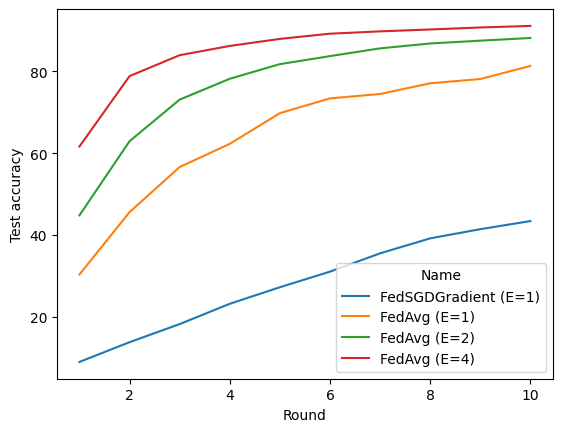

In [28]:
servers: list[Server] = [FedSgdGradientServer(lr, client_split, c, seed)]

for e_ in [1, 2, 4]:
    client_split = split(n, iid, seed)
    servers.append(FedAvgServer(lr, b, client_split, c, e_, seed))

dfs = [sv.run(nr_rounds).as_df() for sv in servers]
df = pd.concat(dfs, ignore_index=True)
df["Name"] = df["Algorithm"] + " (E=" + df["E"].astype(str) + ")"
ax = sns.lineplot(df, x="Round", y="Test accuracy", hue="Name")

All instances of FedAvg achieve a significantly higher accuracy than FedSGD at every step. Bumping the number of local epochs performed by clients during rounds yields further increases in accuracy. Still, the effect advantage diminishes after a certain point compared to the amount of additional work (here, there is a modest difference between 2 and 4, but the amount of computation doubles).

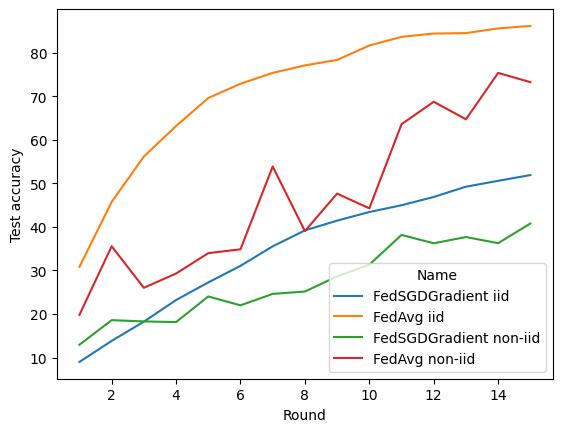

In [29]:
servers: list[Server] = []
iid_strs: list[str] = []

for iid_ in [True, False]:
    client_split = split(n, iid_, seed)
    iid_str = f"{'' if iid_ else 'non-'}iid"
    servers.append(FedSgdGradientServer(lr, client_split, c, seed))
    iid_strs.append(iid_str)
    servers.append(FedAvgServer(lr, b, client_split, c, e, seed))
    iid_strs.append(iid_str)

dfs = [sv.run(15).as_df() for sv in servers]

for df, iid_str in zip(dfs, iid_strs):
    df["Split"] = iid_str

df = pd.concat(dfs, ignore_index=True)
df["Name"] = df["Algorithm"] + " " + df["Split"]
ax = sns.lineplot(df, x="Round", y="Test accuracy", hue="Name", seed=seed)

For both algorithms, learning in the non-IID case is much slower, but most importantly, the learning is much less smooth with the chosen parameters. Although accuracy still follows an overall upward trend, there are often considerable (negative) swings between consecutive steps.

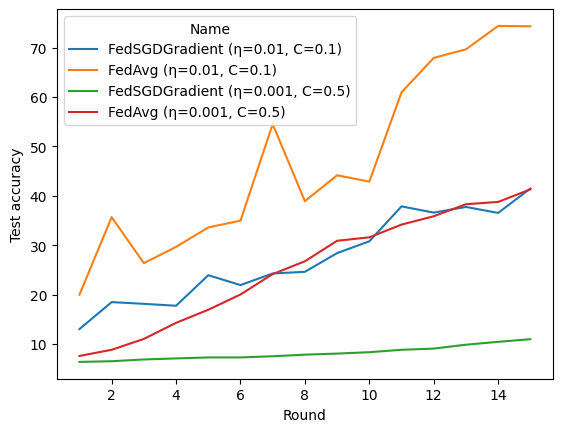

In [30]:
servers: list[Server] = []

for lr_, c_ in [(lr, c), (0.001, 0.5)]:
    client_split = split(n, False, seed)
    servers.append(FedSgdGradientServer(lr_, client_split, c_, seed))
    servers.append(FedAvgServer(lr_, b, client_split, c_, e, seed))

dfs = [sv.run(15).as_df() for sv in servers]
df = pd.concat(dfs, ignore_index=True)
df["Name"] = df["Algorithm"] + f" ({ETA}=" + df[ETA].astype(str) + ", C=" + df["C"].astype(str) + ")"
ax = sns.lineplot(df, x="Round", y="Test accuracy", hue="Name", seed=seed)

Decreasing the learning rate and upping the client fraction increases the stability for both algorithms, but it does mean that reaching the same peak accuracy would require more rounds. A lower learning rate makes for smaller, more conservative steps, which is useful when the data within clients only represents part of the tackled problem. Increasing the fraction of clients called upon in updates helps ensure updates are representative by increasing the chances that any part of the problem (i.e., examples for a class) is better represented in the data of clients involved in the update.